# BCG GenAI Consulting — Task 1: Financial Data Analysis
### AI-Powered Financial Chatbot Project for Global Finance Corp. (GFC)

**Analyst:** Pranjal (Junior Data Scientist)  
**Team:** GenAI Consulting Team, BCG  
**Objective:** Extract, analyze, and prepare key financial data from the 10-K filings of **Microsoft, Tesla, and Apple** (FY2023–FY2025) to inform the development of an AI-powered financial chatbot.

---

## Methodology
1. **Data extraction** — Key figures were manually extracted from each company's 10-K filings on the SEC EDGAR database:
   - Total Revenue
   - Net Income
   - Total Assets
   - Total Liabilities
   - Cash Flow from Operating Activities
2. **Data structuring** — Data was compiled into a spreadsheet / CSV and loaded into a pandas DataFrame.
3. **Trend analysis** — Year-over-year (YoY) growth and key financial ratios were computed with pandas.
4. **Insights** — Findings are summarized to inform the chatbot's knowledge base.

> **Note on fiscal years:** Microsoft's FY ends June 30, Apple's FY ends late September, and Tesla's FY ends December 31. All figures are reported in **millions of USD (US$M)** as stated in each 10-K.

## 1. Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
plt.rcParams['figure.figsize'] = (9, 5)

## 2. Load the Extracted Data

The data extracted from the 10-K filings is loaded below. It is defined inline so the notebook is fully reproducible, and it is also saved to `financial_data.csv` (the same file you would load with `pd.read_csv`).

```python
# Equivalent load from the CSV/Excel export:
# df = pd.read_csv('financial_data.csv')
```

In [2]:
# Financial figures manually extracted from 10-K filings (SEC EDGAR). All values in US$ millions.
data = {
    'Company': ['Microsoft', 'Microsoft', 'Microsoft',
                'Apple', 'Apple', 'Apple',
                'Tesla', 'Tesla', 'Tesla'],
    'Year': [2023, 2024, 2025, 2023, 2024, 2025, 2023, 2024, 2025],
    'Total Revenue': [211915, 245122, 281724, 383285, 391035, 416161, 96773, 97690, 94827],
    'Net Income': [72361, 88136, 101832, 96995, 93736, 112010, 14997, 7091, 3794],
    'Total Assets': [411976, 512163, 619003, 352583, 364980, 359241, 106618, 122070, 137806],
    'Total Liabilities': [205753, 243686, 275524, 290437, 308030, 285508, 43009, 48390, 54941],
    'Cash Flow from Operating Activities': [87582, 118548, 136162, 110543, 118254, 111482, 13256, 14923, 14747]
}

df = pd.DataFrame(data)

# Save a copy so the data can also be loaded via pd.read_csv('financial_data.csv')
df.to_csv('financial_data.csv', index=False)

# Ensure correct ordering for time-series calculations
df = df.sort_values(['Company', 'Year']).reset_index(drop=True)
df

,Company,Year,Total Revenue,Net Income,Total Assets,Total Liabilities,Cash Flow from Operating Activities
0,Apple,2023,383285,96995,352583,290437,110543
1,Apple,2024,391035,93736,364980,308030,118254
2,Apple,2025,416161,112010,359241,285508,111482
3,Microsoft,2023,211915,72361,411976,205753,87582
4,Microsoft,2024,245122,88136,512163,243686,118548
5,Microsoft,2025,281724,101832,619003,275524,136162
6,Tesla,2023,96773,14997,106618,43009,13256
7,Tesla,2024,97690,7091,122070,48390,14923
8,Tesla,2025,94827,3794,137806,54941,14747


## 3. Data Quality Check

Before analysis, confirm the data is clean, complete, and correctly typed — a prerequisite for feeding reliable data into an AI model.

In [3]:
print('Shape (rows, columns):', df.shape)
print('\nMissing values per column:')
print(df.isnull().sum())
print('\nData types:')
print(df.dtypes)

Shape (rows, columns): (9, 7)

Missing values per column:
Company                                0
Year                                   0
Total Revenue                          0
Net Income                             0
Total Assets                           0
Total Liabilities                      0
Cash Flow from Operating Activities    0
dtype: int64

Data types:
Company                                  str
Year                                   int64
Total Revenue                          int64
Net Income                             int64
Total Assets                           int64
Total Liabilities                      int64
Cash Flow from Operating Activities    int64
dtype: object


## 4. Year-over-Year (YoY) Growth Analysis

Using `groupby('Company').pct_change()`, we compute the percentage change of each metric from one fiscal year to the next. The first year for each company is `NaN` because there is no prior year to compare against.

In [4]:
metrics = ['Total Revenue', 'Net Income', 'Total Assets',
           'Total Liabilities', 'Cash Flow from Operating Activities']

for m in metrics:
    df[f'{m} Growth (%)'] = df.groupby('Company')[m].pct_change() * 100

growth_cols = ['Company', 'Year'] + [f'{m} Growth (%)' for m in metrics]
df[growth_cols].round(2)

,Company,Year,Total Revenue Growth (%),Net Income Growth (%),Total Assets Growth (%),Total Liabilities Growth (%),Cash Flow from Operating Activities Growth (%)
0,Apple,2023,NaN,NaN,NaN,NaN,NaN
1,Apple,2024,2.02,-3.36,3.52,6.06,6.98
2,Apple,2025,6.43,19.50,-1.57,-7.31,-5.73
3,Microsoft,2023,NaN,NaN,NaN,NaN,NaN
4,Microsoft,2024,15.67,21.80,24.32,18.44,35.36
5,Microsoft,2025,14.93,15.54,20.86,13.07,14.86
6,Tesla,2023,NaN,NaN,NaN,NaN,NaN
7,Tesla,2024,0.95,-52.72,14.49,12.51,12.58
8,Tesla,2025,-2.93,-46.50,12.89,13.54,-1.18


## 5. Key Financial Ratios (Feature Engineering)

Deriving ratios from the raw figures gives the chatbot richer, normalized indicators of financial health:

- **Net Profit Margin (%)** = Net Income / Total Revenue — how much profit is generated per dollar of revenue.
- **Debt-to-Assets Ratio** = Total Liabilities / Total Assets — the share of assets financed by debt (lower = more solvent).
- **Operating Cash Flow to Net Income** = Operating Cash Flow / Net Income — earnings quality (>1 means profits are well backed by cash).

In [5]:
df['Net Profit Margin (%)'] = (df['Net Income'] / df['Total Revenue']) * 100
df['Debt-to-Assets Ratio'] = df['Total Liabilities'] / df['Total Assets']
df['OCF-to-Net-Income'] = df['Cash Flow from Operating Activities'] / df['Net Income']

ratio_cols = ['Company', 'Year', 'Net Profit Margin (%)', 'Debt-to-Assets Ratio', 'OCF-to-Net-Income']
df[ratio_cols].round(2)

,Company,Year,Net Profit Margin (%),Debt-to-Assets Ratio,OCF-to-Net-Income
0,Apple,2023,25.31,0.82,1.14
1,Apple,2024,23.97,0.84,1.26
2,Apple,2025,26.92,0.79,1.00
3,Microsoft,2023,34.15,0.50,1.21
4,Microsoft,2024,35.96,0.48,1.35
5,Microsoft,2025,36.15,0.45,1.34
6,Tesla,2023,15.50,0.40,0.88
7,Tesla,2024,7.26,0.40,2.10
8,Tesla,2025,4.00,0.40,3.89


## 6. Summary Statistics by Company

In [6]:
summary = df.groupby('Company')[metrics].agg(['mean', 'min', 'max'])
summary.round(0)

Total Revenue                 Net Income                 \
                   mean     min     max       mean    min     max   
Company                                                             
Apple        396,827.00  383285  416161 100,914.00  93736  112010   
Microsoft    246,254.00  211915  281724  87,443.00  72361  101832   
Tesla         96,430.00   94827   97690   8,627.00   3794   14997   

          Total Assets                 Total Liabilities                  \
                  mean     min     max              mean     min     max   
Company                                                                    
Apple       358,935.00  352583  364980        294,658.00  285508  308030   
Microsoft   514,381.00  411976  619003        241,654.00  205753  275524   
Tesla       122,165.00  106618  137806         48,780.00   43009   54941   

          Cash Flow from Operating Activities                  
                                         mean     min     max  
Company                                                        
Apple                              113,426.00  110543  118254  
Microsoft                          114,097.00   87582  136162  
Tesla                               14,309.00   13256   14923

In [7]:
# Average YoY growth per company (a quick view of momentum)
avg_growth = df.groupby('Company')[[f'{m} Growth (%)' for m in metrics]].mean().round(2)
avg_growth

,Total Revenue Growth (%),Net Income Growth (%),Total Assets Growth (%),Total Liabilities Growth (%),Cash Flow from Operating Activities Growth (%)
Company,,,,,
Apple,4.22,8.07,0.97,-0.63,0.62
Microsoft,15.30,18.67,22.59,15.75,25.11
Tesla,-0.99,-49.61,13.69,13.02,5.70


## 7. Visualizing the Trends

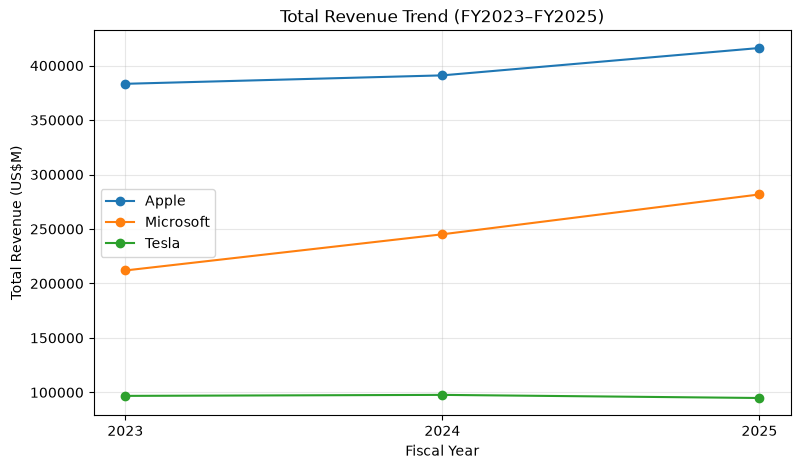

In [8]:
# Total Revenue trend
for company, grp in df.groupby('Company'):
    plt.plot(grp['Year'], grp['Total Revenue'], marker='o', label=company)
plt.title('Total Revenue Trend (FY2023–FY2025)')
plt.xlabel('Fiscal Year'); plt.ylabel('Total Revenue (US$M)')
plt.xticks([2023, 2024, 2025]); plt.legend(); plt.grid(True, alpha=0.3)
plt.show()

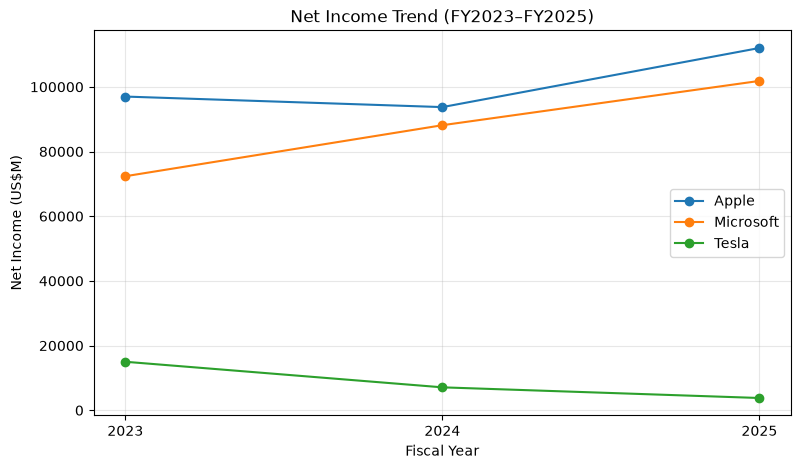

In [9]:
# Net Income trend
for company, grp in df.groupby('Company'):
    plt.plot(grp['Year'], grp['Net Income'], marker='o', label=company)
plt.title('Net Income Trend (FY2023–FY2025)')
plt.xlabel('Fiscal Year'); plt.ylabel('Net Income (US$M)')
plt.xticks([2023, 2024, 2025]); plt.legend(); plt.grid(True, alpha=0.3)
plt.show()

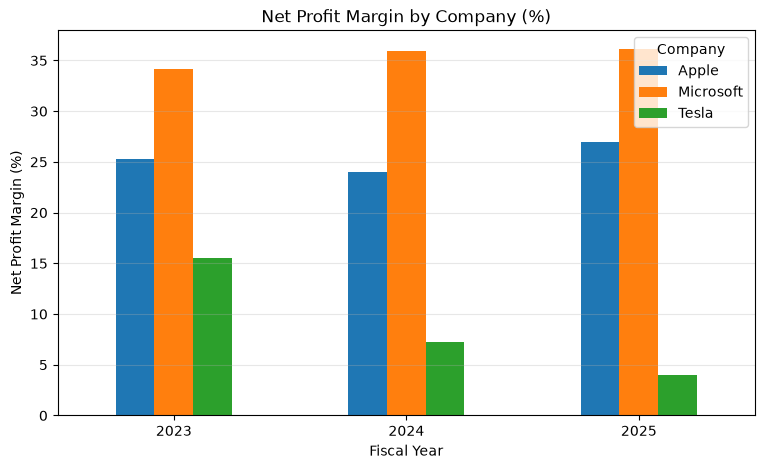

In [10]:
# Net Profit Margin comparison
pivot_margin = df.pivot(index='Year', columns='Company', values='Net Profit Margin (%)')
pivot_margin.plot(kind='bar')
plt.title('Net Profit Margin by Company (%)')
plt.xlabel('Fiscal Year'); plt.ylabel('Net Profit Margin (%)')
plt.xticks(rotation=0); plt.legend(title='Company'); plt.grid(True, axis='y', alpha=0.3)
plt.show()

## 8. Summary of Findings

### 🔹 Microsoft (MSFT) — Strong, broad-based growth
- **Revenue** grew from **$211.9B (FY23)** to **$281.7B (FY25)**, ~**+15.7% per year** — the most consistent grower, driven by cloud (Azure) and AI.
- **Net income** rose from **$72.4B** to **$101.8B**, with a healthy net margin of ~**34–36%**.
- **Operating cash flow** climbed to **$136.2B**, and OCF consistently exceeds net income (earnings are well backed by cash).
- Assets grew faster than liabilities — a low, stable debt-to-assets ratio (~0.44) signals strong solvency.

### 🔹 Apple (AAPL) — Largest scale, highly profitable, flat balance sheet
- **Revenue** is the highest of the three at **$416.2B (FY25)** but grew modestly (~**+4.2% per year**) — a mature business.
- **Net income** dipped in FY24 (**$93.7B**) then rebounded to a record **$112.0B (FY25)**.
- **Highest debt-to-assets ratio** (~0.79–0.84) due to large buybacks and debt-funded capital returns, though offset by very strong, stable operating cash flow (~$110–118B).
- Total assets are roughly flat — Apple returns cash to shareholders rather than accumulating assets.

### 🔹 Tesla (TSLA) — Growing asset base, compressing margins
- **Revenue** is broadly flat (~$95–98B) and slightly declined in FY25 amid pricing pressure and competition.
- **Net income fell sharply** from **$15.0B (FY23)** to **$3.8B (FY25)** — net margin compressed from ~15.5% to ~4.0%.
- Despite falling profit, **total assets grew ~29%** (continued capacity/R&D investment) and **operating cash flow stayed resilient** (~$14.7B), meaning OCF now far exceeds net income.
- Lowest debt-to-assets ratio (~0.40) — the most conservatively financed, but the profitability trend is the key risk to watch.

### Cross-company takeaways for the chatbot
| Insight | Implication for GFC's AI chatbot |
|---|---|
| MSFT = consistent compounder | Flag as strong growth + solvency profile |
| AAPL = mature cash machine, high leverage | Explain margin strength vs. elevated debt ratio |
| TSLA = flat revenue, shrinking profit | Surface margin-compression as an early risk signal |
| OCF > Net Income (all three) | High earnings quality — a useful automated health check |

### Data-preparation notes (for AI integration)
- All figures normalized to **US$ millions** and consistent column names.
- **Year** kept as an integer for time-series ordering; `Company` is the categorical grouping key.
- Engineered features (growth %, margins, ratios) give the model normalized, comparable signals across companies of very different sizes.
- No missing/duplicate values; first-year growth is `NaN` by design (no prior period).

## 9. Export Final Processed Dataset

The enriched dataset (raw figures + growth rates + ratios) is exported for downstream use in the AI chatbot pipeline.

In [11]:
df.round(2).to_csv('financial_data_processed.csv', index=False)
print('Exported: financial_data_processed.csv')
df.round(2).head(9)

Exported: financial_data_processed.csv


,Company,Year,Total Revenue,Net Income,Total Assets,Total Liabilities,Cash Flow from Operating Activities,Total Revenue Growth (%),Net Income Growth (%),Total Assets Growth (%),Total Liabilities Growth (%),Cash Flow from Operating Activities Growth (%),Net Profit Margin (%),Debt-to-Assets Ratio,OCF-to-Net-Income
0,Apple,2023,383285,96995,352583,290437,110543,NaN,NaN,NaN,NaN,NaN,25.31,0.82,1.14
1,Apple,2024,391035,93736,364980,308030,118254,2.02,-3.36,3.52,6.06,6.98,23.97,0.84,1.26
2,Apple,2025,416161,112010,359241,285508,111482,6.43,19.50,-1.57,-7.31,-5.73,26.92,0.79,1.00
3,Microsoft,2023,211915,72361,411976,205753,87582,NaN,NaN,NaN,NaN,NaN,34.15,0.50,1.21
4,Microsoft,2024,245122,88136,512163,243686,118548,15.67,21.80,24.32,18.44,35.36,35.96,0.48,1.35
5,Microsoft,2025,281724,101832,619003,275524,136162,14.93,15.54,20.86,13.07,14.86,36.15,0.45,1.34
6,Tesla,2023,96773,14997,106618,43009,13256,NaN,NaN,NaN,NaN,NaN,15.50,0.40,0.88
7,Tesla,2024,97690,7091,122070,48390,14923,0.95,-52.72,14.49,12.51,12.58,7.26,0.40,2.10
8,Tesla,2025,94827,3794,137806,54941,14747,-2.93,-46.50,12.89,13.54,-1.18,4.00,0.40,3.89
